**1. Import**

In [1]:
# Import

import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
import timm
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import precision_score, recall_score, f1_score
from torch.utils.tensorboard import SummaryWriter
import os


2025-07-24 18:44:54.226875: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753382694.431437      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753382694.487324      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import random
import numpy as np

# Set Seed for Reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


**2. Device & Data Transform**

In [3]:
# Set device & Set Device and Define Data Transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Transforms
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

Using device: cuda


**3. Load Dataset And Class Distribution**

In [4]:
# Load Dataset and Analyze Class Distribution

# Dataset path
DATASET_PATH = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

# Load dataset
dataset = datasets.ImageFolder(root=DATASET_PATH, transform=transform_train)
print("Classes:", dataset.classes)

# Class distribution
labels = [sample[1] for sample in dataset.samples]
label_counts = Counter(labels)
print("Class distribution:", label_counts)

Classes: ['Cyst', 'Normal', 'Stone', 'Tumor']
Class distribution: Counter({1: 5077, 0: 3709, 3: 2283, 2: 1377})


**4. Split Dataset & Create Balanced Sampler**

In [5]:
# Split dataset first
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.2 * total_size)
test_size = total_size - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Apply transform_test to val and test
val_dataset.dataset.transform = transform_test
test_dataset.dataset.transform = transform_test

# Compute class weights ONLY for train_dataset
train_labels = [dataset[i][1] for i in train_dataset.indices]
train_counts = Counter(train_labels)
class_weights = [1.0 / train_counts[label] for label in train_labels]
sampler = WeightedRandomSampler(class_weights, num_samples=len(train_labels), replacement=True)


**Split sizes**

In [6]:
# Verify split sizes
print("Train Dataset Size:", len(train_dataset))
print("Validation Dataset Size:", len(val_dataset))
print("Test Dataset Size:", len(test_dataset))

Train Dataset Size: 8712
Validation Dataset Size: 2489
Test Dataset Size: 1245


**5. Create DataLoaders for Training, Validation, and Testing**

In [7]:
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


**6. Swin Transformer**

In [8]:
# Swin Transformer Model
class SwinClassifier(nn.Module):
    def __init__(self, num_classes):
        super(SwinClassifier, self).__init__()
        self.model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)


**7. Initialize Model, Loss Function, Optimizer, and Scaler**

In [9]:
# Initialize model
num_classes = len(dataset.classes)
model = SwinClassifier(num_classes=num_classes).to(device)

# Optimizer and loss
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
scaler = GradScaler()

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

/tmp/ipykernel_36/699395065.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


**8. Training Function with AMP and Early Stopping**

In [10]:
# Training function with AMP
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=300):
    best_val_loss = float('inf')
    patience = 3
    counter = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0
        
        # === Training Loop ===
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            # Automatic Mixed Precision
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

        train_loss = total_loss / len(train_loader.dataset)
        train_acc = 100. * correct / len(train_loader.dataset)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        total_val_loss, val_correct = 0, 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} Validation"):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                total_val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = total_val_loss / len(val_loader.dataset)
        val_acc = 100. * val_correct / len(val_loader.dataset)
        val_losses.append(val_loss)

        precision = precision_score(all_labels, all_preds, average='macro')
        recall = recall_score(all_labels, all_preds, average='macro')
        f1 = f1_score(all_labels, all_preds, average='macro')

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")
        print(f"Precision={precision:.4f}, Recall={recall:.4f}, F1 Score={f1:.4f}")

        writer.add_scalar("Loss/Train", train_loss, epoch)
        writer.add_scalar("Loss/Val", val_loss, epoch)
        writer.add_scalar("Accuracy/Train", train_acc, epoch)
        writer.add_scalar("Accuracy/Val", val_acc, epoch)
        writer.add_scalar("Precision/Val", precision, epoch)
        writer.add_scalar("Recall/Val", recall, epoch)
        writer.add_scalar("F1/Val", f1, epoch)
        
        # === Early Stopping & Save Best Model ===
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            counter = 0
            torch.save(model.state_dict(), '/kaggle/working/best_model.pth')

        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break
    print(f"\n✅ Best Model was from Epoch {best_epoch} with Val Loss: {best_val_loss:.4f}")
    
    # Plot loss
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend()
    plt.title("Loss Curve")
    plt.show()
    


**9. TensorBoard Logger**

In [11]:
writer = SummaryWriter(log_dir="/kaggle/working/runs/swin_ct_kidney")

**10. Training**

Epoch 1 Training:   0%|          | 0/273 [00:00<?, ?it/s]/tmp/ipykernel_36/937144871.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1 Validation: 100%|██████████| 78/78 [00:39<00:00,  1.97it/s]


Epoch 1: Train Loss=0.1720, Val Loss=0.0280, Train Acc=93.69%, Val Acc=99.24%
Precision=0.9918, Recall=0.9860, F1 Score=0.9889


Epoch 2 Training:   0%|          | 0/273 [00:00<?, ?it/s]/tmp/ipykernel_36/937144871.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 2 Validation: 100%|██████████| 78/78 [00:27<00:00,  2.88it/s]


Epoch 2: Train Loss=0.0499, Val Loss=0.1029, Train Acc=98.46%, Val Acc=96.58%
Precision=0.9725, Recall=0.9598, F1 Score=0.9650


Epoch 3 Training:   0%|          | 0/273 [00:00<?, ?it/s]/tmp/ipykernel_36/937144871.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 3 Validation: 100%|██████████| 78/78 [00:27<00:00,  2.85it/s]


...

Epoch 6: Train Loss=0.0217, Val Loss=0.0354, Train Acc=99.46%, Val Acc=98.96%
Precision=0.9856, Recall=0.9858, F1 Score=0.9856


Epoch 7 Training:   0%|          | 0/273 [00:00<?, ?it/s]/tmp/ipykernel_36/937144871.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 7 Validation: 100%|██████████| 78/78 [00:26<00:00,  2.90it/s]


Epoch 7: Train Loss=0.0309, Val Loss=0.0666, Train Acc=99.16%, Val Acc=98.11%
Precision=0.9848, Recall=0.9568, F1 Score=0.9686


Epoch 8 Training:   0%|          | 0/273 [00:00<?, ?it/s]/tmp/ipykernel_36/937144871.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 8 Validation: 100%|██████████| 78/78 [00:26<00:00,  2.91it/s]

Epoch 8: Train Loss=0.0106, Val Loss=0.0766, Train Acc=99.68%, Val Acc=98.23%
Precision=0.9859, Recall=0.9739, F1 Score=0.9794
Early stopping triggered.

✅ Best Model was from Epoch 5 with Val Loss: 0.0082


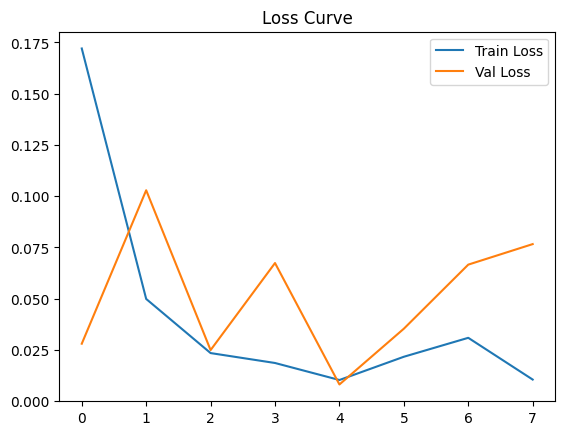

In [12]:
# Start training
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=300)

In [13]:
writer.close()

In [14]:
%load_ext tensorboard
%tensorboard --logdir runs


<IPython.core.display.Javascript object>

In [15]:
 %reload_ext tensorboard

**11. Evaluation on Test Set**

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Testing"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    print(f"\nTest Accuracy: {accuracy:.4f}")
    print(f"Test Precision: {precision:.4f}")
    print(f"Test Recall: {recall:.4f}")
    print(f"Test F1 Score: {f1:.4f}")

# Evaluate on test set
evaluate_model(model, test_loader)

Testing: 100%|██████████| 39/39 [00:20<00:00,  1.89it/s]


Test Accuracy: 0.9855
Test Precision: 0.9890
Test Recall: 0.9788
Test F1 Score: 0.9834


In [17]:
from sklearn.metrics import classification_report, accuracy_score

def evaluate_model(model, test_loader, class_names=None):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Testing"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # === Overall Metrics ===
    accuracy = accuracy_score(all_labels, all_preds)
    print(f"\nOverall Accuracy: {accuracy:.4f}")

    # === Per-Class Metrics ===
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))


**12. Classification Report**

In [18]:
class_names = ['Cyst', 'Normal', 'Stone', 'Tumor']
evaluate_model(model, test_loader, class_names)

Testing: 100%|██████████| 39/39 [00:14<00:00,  2.78it/s]


Overall Accuracy: 0.9855

Classification Report:
              precision    recall  f1-score   support

        Cyst     0.9638    1.0000    0.9816       373
      Normal     0.9923    1.0000    0.9961       513
       Stone     1.0000    0.9929    0.9964       140
       Tumor     1.0000    0.9224    0.9596       219

    accuracy                         0.9855      1245
   macro avg     0.9890    0.9788    0.9834      1245
weighted avg     0.9860    0.9855    0.9854      1245

